In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
DATA_ROOT = '/data2/a330d' #os.environ.get("DATA_ROOT", ".")
import numpy as np
import glob
import numpy as np
import json
import matplotlib as mpl
#mpl.rcParams["font.family"] = "monospace"

from plotting import plot_model_comparison

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset_name = "crc" # Options: merfish, crc

In [ ]:
corr_dir = os.path.join(DATA_ROOT, f"datasets/{dataset_name}/correlations")
pattern = os.path.join(corr_dir, "*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    core = name[len("crc_"):-len(".json")] if dataset_name == "crc" else name[:-len(".json")]
    parts = core.split("_")
    sid = parts[0]
    model_name = parts[1]
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": f"crc_{sid}" if dataset_name == "crc" else sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "direction_match_gt": data.get("direction_match_gt"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),
            "edistance_pca": data.get("edistance_pca"),
            "edistance_pca_log": data.get("edistance_pca_log"),           
            "rmse": data.get("rmse"),
            "mse_lfc": data.get("mse_lfc"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

data_df = pd.DataFrame(rows)
data_df.head()

In [ ]:
# Remove -cf from the end of each model_name
data_df["model_name"] = data_df["model_name"].str.replace("-cf", "", regex=False)
n_deg = data_df["n_deg"].iloc[0]
data_df.head()

In [ ]:
df = data_df.copy() # start with existing dataframe
df["sid"] = df["sid"].astype(str)

In [8]:
def unify_formatting(df_parent, df_child):
    df_child["holdout_celltype"] = df_child["holdout_celltype"] + "_" + df_child["target_domain"]
    df_child["sid"] = df_child["sid"].astype(str)

    common_cols = df_parent.columns
    df_child_trimmed = df_child[common_cols.intersection(df_child.columns)]
    combined = pd.concat([df_parent, df_child_trimmed], axis=0, ignore_index=True)

    return combined

In [ ]:
load_strict_cf = True

if load_strict_cf:
    # Remove rows with model_name in ['cellina', 'cellina-graph', 'cellina-ablated']
    exclude_models = ['cellina', 'cellina-graph', 'cellina-ablated']
    df = df[~df['model_name'].isin(exclude_models)].copy()

    # Load and concatenate the new results from the strict counterfactual experiment to existing df
    strict_cf_path = f'../results/loo_cellina_{dataset_name}_DEG_{n_deg}_strict_cf.csv'
    strict_cf_df = pd.read_csv(strict_cf_path)
    strict_cf_df["sid"] = strict_cf_df["sid"].astype(str)
    combined_df = unify_formatting(df, strict_cf_df)

In [ ]:
# Load mintflow results
mintflow_base_path = f"../results/mintflow_{dataset_name}"
mintflow_df = pd.DataFrame()

# Loop over mintflow_base_path and read each file, concatenate into mintflow_df
for file in glob.glob(f"{mintflow_base_path}/mintflow_*.csv"):
    temp_df = pd.read_csv(file)
    mintflow_df = pd.concat([mintflow_df, temp_df], ignore_index=True)
    mintflow_df = mintflow_df[mintflow_df["n_deg"] == n_deg]
mintflow_df.head()

In [ ]:
combined_df = unify_formatting(combined_df, mintflow_df)

In [ ]:
# Add node-perturbation results
cellina_pert_df = pd.read_csv(f"../results/loo_cellina_{dataset_name}_DEG_{int(n_deg)}_pert.csv")
combined_df = unify_formatting(combined_df, cellina_pert_df)

In [ ]:
spprop_pert_df = pd.read_csv(f"../results/loo_spatialprop_{dataset_name}_DEG_{int(n_deg)}_pert.csv")
spprop_pert_df['model_name'] += "-pert"
combined_df = unify_formatting(combined_df, spprop_pert_df)

In [ ]:
combined_df.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}.csv", index=False)

***

In [13]:
n_deg = 50
cellina_w_df = pd.read_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}_W.csv")
combined_df = pd.read_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}.csv")

# Remove rows of combined_df where model_name contains 'cellina'
combined_df = combined_df[~combined_df["model_name"].str.contains("cellina")].copy()
# Add cellina_w_df to combined_df
combined_df = pd.concat([combined_df, cellina_w_df], ignore_index=True)
# Remove '-W' from the end of any model_name in combined_df
combined_df["model_name"] = combined_df["model_name"].str.replace("-W", "", regex=False)

In [14]:
combined_df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca,edistance_pca_log,rmse,mse_lfc
0,crc_120,baseline,Endothelial_CRC,50,0.548619,0.497170,0.10,1.000000,0.10,0.98,0.547060,80.808913,81.675932,427.805696,25.682925,5856.333946,23.428992
1,crc_120,baseline,Epithelial_CRC,50,0.442017,0.330887,0.26,0.769231,0.20,0.64,0.895650,68.697979,67.793183,1273.103803,56.871974,652016.069078,100.027156
2,crc_120,baseline,Fibroblast_CRC,50,0.378247,0.385970,0.16,1.000000,0.16,0.66,0.605086,83.590646,83.761561,1151.476451,29.853784,180004.851410,26.908052
3,crc_120,baseline,Myeloid_CRC,50,0.510492,0.456200,0.14,1.000000,0.14,0.74,0.502754,81.759082,82.084297,498.723064,27.389312,36416.168085,28.587862
4,crc_120,baseline,T_cell_CRC,50,0.836351,0.712031,0.12,1.000000,0.12,0.96,0.797638,87.454857,91.051392,307.748382,26.010132,22608.232002,30.237885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,crc_242,cellina-gat-pert,Fibroblast_CRC,50,0.861032,0.846464,0.44,1.000000,0.44,1.00,0.606378,80.030772,77.960005,466.850162,7.940364,31532.001690,1.669804
326,crc_242,cellina-pert,Myeloid_CRC,50,0.756639,0.884284,0.48,1.000000,0.48,0.98,0.870256,62.771968,63.848904,239.372183,6.818424,5272.439157,1.253468
327,crc_242,cellina-gat-pert,Myeloid_CRC,50,0.806098,0.904009,0.46,1.000000,0.46,1.00,0.990000,70.436562,69.334302,301.492641,6.982185,5365.689485,1.271447
328,crc_242,cellina-pert,T_cell_CRC,50,0.866315,0.911165,0.40,1.000000,0.40,1.00,0.746322,85.732702,90.067107,139.573641,6.571071,18819.163584,0.436246


In [27]:
combined_df.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}.csv", index=False)

***

In [15]:
combined_df["model_name"] = combined_df["model_name"].replace("cellina-graph", "cellina-gat")
combined_df = combined_df.rename(columns={"direction_match_k": "signed_precision"})
combined_df = combined_df.rename(columns={"edistance_pca_log": "e-distance"})

In [16]:
combined_df['rmse'] = np.log10(combined_df['rmse'])
combined_df['rmse_lfc'] = np.sqrt(combined_df['mse_lfc'])

In [17]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "cpa",
    "scgen",
    "mintflow",
    "cellina-ablated",
    "cellina",
    "cellina-gat",
    "spatialprop-pert",
    "cellina-pert",
    "cellina-gat-pert",
]

default_palette = 'colorblind'
palette = default_palette

In [18]:
palette_dict = {
    'cellina': '#8172B2',
    'cellina-pert': '#8172B2',
    'cellina-ablated': "#BCB8C9",
    'cellina-gat': "#573BB1",
    'cellina-gat-pert': "#573BB1",
    'scgen':   'orange',
    'cpa':     "#8A5816",
    'mintflow':    'green',
    'spatialprop-pert': 'skyblue',
    'baseline':  'red',
}
palette = palette_dict

In [19]:
# Rename holdout_celltype by replacing the last '_' in with '-'
if dataset_name == "merfish":
    combined_df["holdout_celltype"] = combined_df["holdout_celltype"].str.replace("Fiber_tracts", "Fiber-tracts", regex=False)
else:
    combined_df["holdout_celltype"] = combined_df["holdout_celltype"].str.replace("T_cell", "T-cell", regex=False)

In [20]:
# Split holdout_celltype on '_' and place everything in [0] as holdout_celltype, and everything in [1:] as perturbation
combined_df["perturbation"] = combined_df["holdout_celltype"].apply(lambda x: "".join(x.split("_")[-1]) if len(x.split("_")) > 1 else "")
combined_df["holdout_celltype"] = combined_df["holdout_celltype"].apply(lambda x: "-".join(x.split("_")[:-1]))
combined_df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,signed_precision,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca,e-distance,rmse,mse_lfc,rmse_lfc,perturbation
0,crc_120,baseline,Endothelial,50,0.548619,0.497170,0.10,1.000000,0.10,0.98,0.547060,80.808913,81.675932,427.805696,25.682925,3.767626,23.428992,4.840350,CRC
1,crc_120,baseline,Epithelial,50,0.442017,0.330887,0.26,0.769231,0.20,0.64,0.895650,68.697979,67.793183,1273.103803,56.871974,5.814258,100.027156,10.001358,CRC
2,crc_120,baseline,Fibroblast,50,0.378247,0.385970,0.16,1.000000,0.16,0.66,0.605086,83.590646,83.761561,1151.476451,29.853784,5.255284,26.908052,5.187297,CRC
3,crc_120,baseline,Myeloid,50,0.510492,0.456200,0.14,1.000000,0.14,0.74,0.502754,81.759082,82.084297,498.723064,27.389312,4.561294,28.587862,5.346762,CRC
4,crc_120,baseline,T-cell,50,0.836351,0.712031,0.12,1.000000,0.12,0.96,0.797638,87.454857,91.051392,307.748382,26.010132,4.354267,30.237885,5.498899,CRC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,crc_242,cellina-gat-pert,Fibroblast,50,0.861032,0.846464,0.44,1.000000,0.44,1.00,0.606378,80.030772,77.960005,466.850162,7.940364,4.498752,1.669804,1.292209,CRC
326,crc_242,cellina-pert,Myeloid,50,0.756639,0.884284,0.48,1.000000,0.48,0.98,0.870256,62.771968,63.848904,239.372183,6.818424,3.722012,1.253468,1.119584,CRC
327,crc_242,cellina-gat-pert,Myeloid,50,0.806098,0.904009,0.46,1.000000,0.46,1.00,0.990000,70.436562,69.334302,301.492641,6.982185,3.729626,1.271447,1.127584,CRC
328,crc_242,cellina-pert,T-cell,50,0.866315,0.911165,0.40,1.000000,0.40,1.00,0.746322,85.732702,90.067107,139.573641,6.571071,4.274600,0.436246,0.660489,CRC


In [ ]:
combined_df_1 = combined_df[combined_df["perturbation"].str.contains("Isocortex")]
combined_df_2 = combined_df[combined_df["perturbation"].str.contains("Fiber-tracts")]

In [ ]:
# Split celltype column on empty space and take the first part as new celltype column
combined_df_1["holdout_celltype"] = combined_df_1["holdout_celltype"].str.split(" ").str[0]
combined_df_2["holdout_celltype"] = combined_df_2["holdout_celltype"].str.split(" ").str[0]

In [21]:
metric_labels = {
    "pearson": r"Pearson $r$ ↑",
    "spearman": r"Spearman $\rho$ ↑",
    "signed_precision": r"Signed Precision ↑",
    "e-distance": r"E-distance ↓",
    "rmse": r"$\mathrm{RMSE}_{\mathrm{counts}}$ ↓",
    "rmse_lfc": r"$\mathrm{RMSE}_{\mathrm{LFC}}$ ↓"
}

In [22]:
from matplotlib.patches import Patch

def plot_model_comparison(
    dataset_name,
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_path="../figures",
    save_name="ood_summary",
    hide=False,
    legend_only=False,
    metric_labels=None,
    source_domain=None,
    target_domain=None,
):
    hatch_map = {
    "cellina-pert": "///",
    "cellina-gat-pert": "///",
    "spatialprop-pert": "///",
    }

    if legend_only:
        fig = plt.figure(figsize=(6, 1))
        handles = [
            Patch(
                facecolor=palette[m],
                edgecolor="black" if m in hatch_map else "none",
                hatch=hatch_map[m] if m in hatch_map else "",
                label=m
            )
            for m in model_order
        ]
        fig.legend(handles, model_order, ncol=len(model_order), loc="center", fontsize=16)
        plt.axis("off")
        if save:
            plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
        plt.show()
        return
    
    # Compute global y-limits
    ymin = df[metrics].min().min() * 0.3
    ymax = df[metrics].max().max() * 1.05

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    n_deg = df["n_deg"].iloc[0]    

    title = f"{dataset_name}: Performance for DEG {n_deg} ({source_domain} → {target_domain})"
    if hide:
        title = ""
    fig.suptitle(title, fontsize=20)

    # Ensure axes iterable if only one metric
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        if not average_only:
            # -------------------------------
            # Per-celltype plot
            # -------------------------------
            celltypes = df[grouping].unique().tolist()
            all_x_labels = list(celltypes)

            ymin = df[metric].min().min() * 0.3
            ymax = df[metric].max().max() * 1.05

            sns.barplot(
                data=df,
                x=grouping,
                y=metric,
                hue="model_name",
                estimator="mean",
                errorbar="se",
                hue_order=model_order,
                ax=ax,
                palette=palette,
                order=celltypes,
                dodge=True,
                width=.85,
            )

            for container, model in zip(ax.containers, model_order):
                if model in hatch_map:
                    for bar in container:
                        bar.set_hatch(hatch_map[model])
                        bar.set_linewidth(1.0)
            
            ax.legend_.remove()

            for container, model in zip(ax.containers, model_order):
                for bar in container:
                    
                    # always light grey border for base bars
                    bar.set_edgecolor("lightgrey")
                    bar.set_linewidth(0.8)

                    # if hatch model → overlay a hatch-only bar
                    if model in hatch_map:
                        ax.add_patch(
                            plt.Rectangle(
                                (bar.get_x(), bar.get_y()),
                                bar.get_width(),
                                bar.get_height(),
                                fill=False,
                                hatch=hatch_map[model],
                                edgecolor="black",   # hatch color
                                linewidth=0
                            )
                        )

            ax.set_xticks(range(len(all_x_labels)))
            ax.set_xticklabels(all_x_labels, rotation=20)
            ax.tick_params(axis="y", labelsize=12)
            ax.tick_params(axis="x", labelsize=12)
            ax.set_ylim(ymin, ymax)
        

        else:
            # -------------------------------
            # AVERAGE-ONLY plot (clean)
            # -------------------------------
            df_avg = (
                df.groupby(["model_name"])[metric]
                .agg(["mean", "sem"])
                .reset_index()
            )

            sns.barplot(
                data=df_avg,
                x="model_name",
                y="mean",
                hue="model_name",
                order=model_order,
                palette=palette,
                errorbar=None,  # we add manually
                ax=ax,
            )

            # Add SE manually
            for i, model in enumerate(model_order):
                row = df_avg[df_avg.model_name == model].iloc[0]
                ax.errorbar(
                    x=i,
                    y=row["mean"],
                    yerr=row["sem"],
                    fmt="none",
                    capsize=0,
                    color="black",
                )

            #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.tick_params(axis="x", rotation=45)

        # -------------------------------
        # Shared styling
        # -------------------------------
        
        label = metric_labels.get(metric, metric) if metric_labels else metric
        ax.set_title(label, fontsize=18)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # -------------------------------
    # Global legend (only once)
    # -------------------------------
    if not average_only:
        handles, labels = axes[0].get_legend_handles_labels()
    else:
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=palette[m])
            for m in model_order
        ]
        labels = model_order

    #if hide:
    # Set legend visible False
    handles = []
    labels = []
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    if save:
        plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
    plt.show()

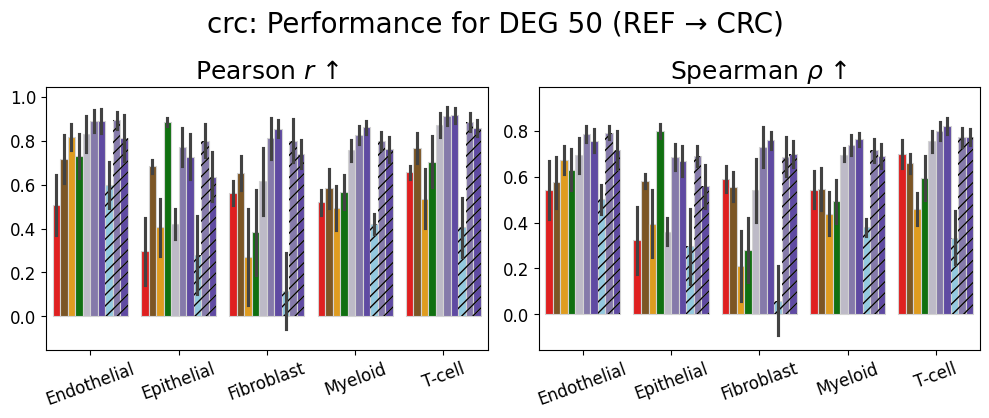

In [24]:
metrics = ["pearson", "spearman"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_1",
    hide=False,
    metric_labels=metric_labels,
    source_domain="REF",
    target_domain="CRC",
)

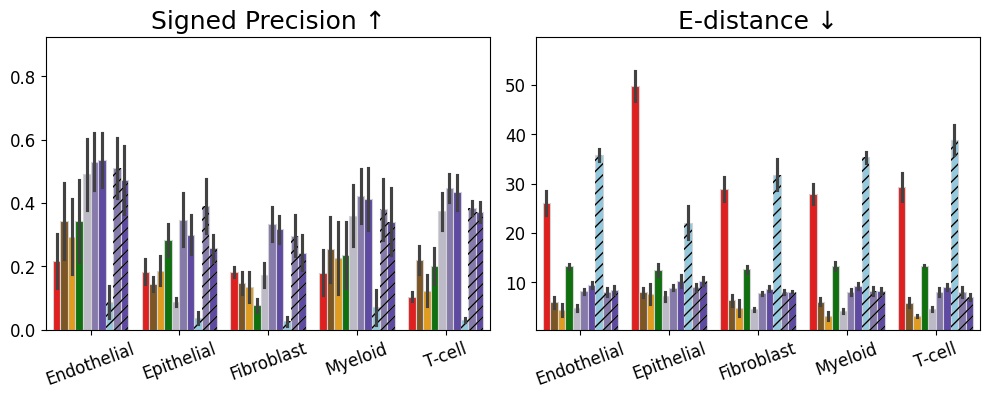

In [25]:
metrics = ["signed_precision", "e-distance"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_2",
    hide=True,
    metric_labels=metric_labels,
    source_domain="REF",
    target_domain="CRC",
)

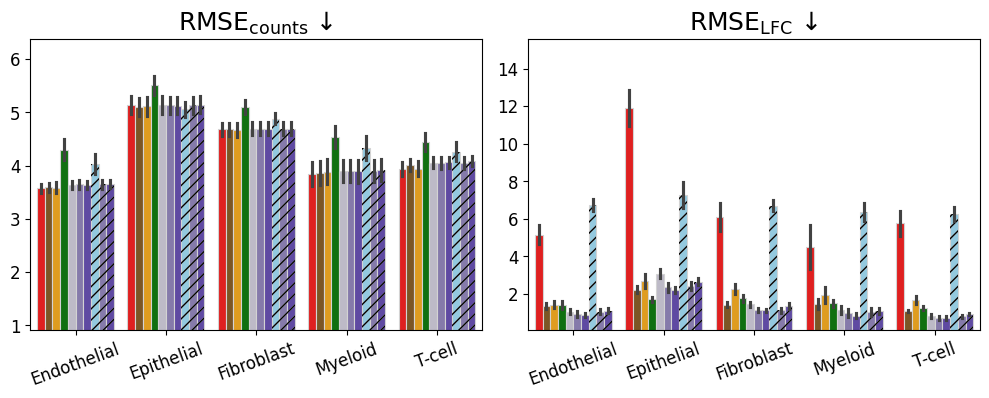

In [26]:
metrics = ["rmse", "rmse_lfc"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_3",
    hide=True,
    metric_labels=metric_labels,
    source_domain="REF",
    target_domain="CRC",
)

***

In [ ]:
metrics = ["pearson", "spearman"]
plot_model_comparison(
    dataset_name,
    combined_df_1,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Isocortex_1",
    hide=False,
    metric_labels=metric_labels,
    source_domain="Thalamus",
    target_domain="Isocortex",
)

In [ ]:
metrics = ["signed_precision", "e-distance"]
plot_model_comparison(
    dataset_name,
    combined_df_1,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Isocortex_2",
    hide=True,
    metric_labels=metric_labels,
    source_domain="Thalamus",
    target_domain="Isocortex",
)

In [ ]:
metrics = ["rmse", "rmse_lfc"]
plot_model_comparison(
    dataset_name,
    combined_df_1,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Isocortex_3",
    hide=True,
    metric_labels=metric_labels,
    source_domain="Thalamus",
    target_domain="Isocortex",
)

In [ ]:
metrics = ["pearson", "spearman"]
plot_model_comparison(
    dataset_name,
    combined_df_2,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Fiber-tracts_1",
    hide=False,
    metric_labels=metric_labels,
    source_domain="Thalamus",
    target_domain="Fiber-tracts",
)

In [ ]:
metrics = ["signed_precision", "e-distance"]
plot_model_comparison(
    dataset_name,
    combined_df_2,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Fiber-tracts_2",
    hide=True,
    metric_labels=metric_labels
)

In [ ]:
metrics = ["rmse", "rmse_lfc"]
plot_model_comparison(
    dataset_name,
    combined_df_2,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Fiber-tracts_3",
    hide=True,
    metric_labels=metric_labels
)

In [ ]:
combined_df.isna().sum()

## Add average rank column

In [ ]:
metrics = [
    "pearson",
    #"spearman",
    "precision",
    #"direction_match",
    #"rmse",
    "edistance_local",
]

direction = {
    "pearson": "higher",
    #"spearman": "higher",
    "precision": "higher",
    #"direction_match": "higher",
    #"rmse": "lower",
    "edistance_local": "lower",
}

In [ ]:
df_ranked = combined_df.copy()

# compute ranks only temporarily
rank_cols = []
group_cols = ["sid", "holdout_celltype"]

for m in metrics:
    ascending = direction[m] == "lower"

    rank_col = f"{m}_rank"
    df_ranked[rank_col] = (
        df_ranked.groupby(group_cols)[m]
        .rank(ascending=ascending, method="average")
    )
    rank_cols.append(rank_col)

# final aggregate rank
df_ranked["avg_rank"] = df_ranked[rank_cols].mean(axis=1)

# drop intermediate rank columns
df_ranked = df_ranked.drop(columns=rank_cols)

In [ ]:
df_ranked

In [ ]:
df_ranked.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}_ranked.csv", index=False)